# 01 — Análise Exploratória

**Projeto:** detecção de páginas de phishing a partir de atributos da URL e do HTML.

**Dataset:** *Phishing Dataset for Machine Learning: Feature Evaluation*
(Tan, 2018 — Mendeley Data, CC BY 4.0), distribuído no Kaggle.
10.000 URLs rotuladas, 48 atributos.


**Premissa de custo, definida antes de olhar os dados** (`config.CostMatrix`):
um phishing não detectado custa **10x** um site legítimo bloqueado. Isso
determina as métricas usadas no notebook 02 e o limiar de decisão final.

---

## O que este notebook responde

1. Os dados têm defeitos estruturais? (auditoria)
2. As 419 duplicatas são erro de coleta ou informação real?
3. Como as classes se distribuem, e o que isso implica para as métricas?
4. Quais features separam phishing de legítimo?
5. Há redundância entre as features?
6. Dá para detectar phishing só com a URL, sem baixar a página?

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from phishing import config, data

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

raw = data.load_raw()
print("Formato:", raw.shape)
raw.head()

Formato: (10000, 50)


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,NumQueryComponents,NumAmpersand,NumHash,NumNumericChars,NoHttps,RandomString,IpAddress,DomainInSubdomains,DomainInPaths,HttpsInHostname,HostnameLength,PathLength,QueryLength,DoubleSlashInPath,NumSensitiveWords,EmbeddedBrandName,PctExtHyperlinks,PctExtResourceUrls,ExtFavicon,InsecureForms,RelativeFormAction,ExtFormAction,AbnormalFormAction,PctNullSelfRedirectHyperlinks,FrequentDomainNameMismatch,FakeLinkInStatusBar,RightClickDisabled,PopUpWindow,SubmitInfoToEmail,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,21,44,0,0,0,0,0.000,0.250000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,0,2,1,0,41,1,0,0,0,0,0,17,16,103,0,1,0,0.000,0.000000,0,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,27,24,0,0,0,0,0.375,1.000000,1,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,22,50,0,0,0,1,1.000,0.095238,1,1,0,0,0,0.0,1,0,0,0,1,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,0,0,0,0,2,1,1,0,0,1,0,10,29,0,0,0,0,1.000,1.000000,0,0,0,1,0,0.0,1,0,0,0,0,1,0,0,1,1,-1,0,-1,-1,1


## 1. Auditoria

Auditoria e EDA são coisas diferentes. **Auditoria procura defeitos**, nulos,
duplicatas, colunas mortas, tipos errados.
**EDA procura padrões**; é exploração aberta.

A auditoria vem primeiro porque interpretar correlações de um dataset com
problema estrutural leva a conclusões erradas com confiança.

In [3]:
print("Valores ausentes:", raw.isna().sum().sum())
print("Tipos:", dict(raw.dtypes.value_counts().astype(int)))

dups = raw.drop(columns=[config.ID_COLUMN]).duplicated().sum()
print(f"Linhas duplicadas (ignorando o id): {dups}")

const = [c for c in raw.columns if raw[c].nunique() <= 1]
print("Colunas constantes:", const)

print("\nBalanceamento:")
print(raw[config.TARGET].value_counts().to_string())

Valores ausentes: 0
Tipos: {dtype('int64'): np.int64(47), dtype('float64'): np.int64(3)}
Linhas duplicadas (ignorando o id): 419
Colunas constantes: ['HttpsInHostname']

Balanceamento:
CLASS_LABEL
1    5000
0    5000


### Leitura dos achados

**Zero nulos.** Nenhum imputador é necessário.

**Todas as colunas numéricas.** Nenhum encoding categórico necessário.

**`HttpsInHostname` é constante (sempre 0).** Variância zero, informação zero.
Não atrapalha uma árvore, mas quebra normalizações (divisão por zero) e polui
gráficos de importância.

**419 linhas duplicadas.** Este é o achado que define o projeto, e a próxima
seção investiga sua origem antes de decidir o que fazer com elas.

> O `id` precisa sair **antes** do `drop_duplicates`. Ele é único por
> construção: se ficar, nenhuma duplicata é encontrada. Erro de uma linha,
> consequência de projeto inteiro.

---

## 2. As duplicatas são erro de coleta ou informação real?

A pergunta não é acadêmica. Se forem **erro**, remover é obviamente correto.
Se forem **reais**, URLs distintas que geram o mesmo vetor, remover joga
fora informação sobre a frequência real dos padrões.

Três evidências decidem.

In [4]:
feats = raw.drop(columns=[config.ID_COLUMN, config.TARGET])

# Evidência 1: o espaço de features comporta colisões?
nun = feats.nunique()
print(f"Features binárias:            {(nun == 2).sum():>2} de {len(nun)}")
print(f"Features com <= 10 valores:   {(nun <= 10).sum():>2} de {len(nun)}")
print(f"Features realmente contínuas: {(nun > 50).sum():>2} de {len(nun)}")

Features binárias:            23 de 48
Features com <= 10 valores:   32 de 48
Features realmente contínuas:  8 de 48


**23 features binárias, 32 com no máximo 10 valores distintos, só 8 contínuas.**
O espaço efetivo é muito menor que "48 dimensões" sugere. Uma página simples
poucos links, sem formulário, sem iframe 

In [5]:
sem_rotulo = feats.duplicated().sum()
com_rotulo = raw.drop(columns=[config.ID_COLUMN]).duplicated().sum()

print(f"Duplicatas só nas features:      {sem_rotulo}")
print(f"Duplicatas features + rótulo:    {com_rotulo}")
print(f"=> Grupos com rótulo conflitante: {sem_rotulo - com_rotulo}")

Duplicatas só nas features:      419
Duplicatas features + rótulo:    419
=> Grupos com rótulo conflitante: 0


**Evidência 2: zero conflitos de rótulo.** Todas as cópias de cada grupo
carregam o mesmo `CLASS_LABEL`. Se fossem erro de anotação, esperaríamos ao
menos alguns grupos divergentes. Não há nenhum.

In [6]:
sem_id = raw.drop(columns=[config.ID_COLUMN])

grupos = sem_id.groupby(list(sem_id.columns)).size()
grupos = grupos[grupos > 1].sort_values(ascending=False)

print(f"Grupos duplicados: {len(grupos)}")
print(f"Maior grupo: {grupos.iloc[0]} cópias idênticas\n")
print("Distribuição do tamanho dos grupos:")
print(grupos.value_counts().sort_index().rename("n_grupos").to_string())

envolvidas = sem_id[sem_id.duplicated(keep=False)]
print("\nLinhas envolvidas em duplicação, por classe:")
print(envolvidas[config.TARGET].value_counts().to_string())

Grupos duplicados: 257
Maior grupo: 17 cópias idênticas

Distribuição do tamanho dos grupos:
2     176
3      48
4      14
5      11
6       2
7       3
8       1
11      1
17      1

Linhas envolvidas em duplicação, por classe:
CLASS_LABEL
1    671
0      5


**Evidência 3: a assimetria é brutal.** Das linhas envolvidas em duplicação,
**671 são phishing e apenas 5 são legítimas** — e há um grupo com **17 cópias
idênticas**, todas phishing.

### A interpretação: kits de phishing

Atacantes usam *templates* prontos. O mesmo kit "Login PayPal" implantado em
17 domínios diferentes gera 17 páginas com estrutura HTML idêntica, logo 17
vetores idênticos. Sites legítimos são artesanais e variados; páginas de
phishing são industrializadas.

**As duplicatas não são defeito do dataset, são retrato fiel do modus operandi.**

### Então por que removê-las?

Porque há **dois problemas distintos**, com gravidades diferentes:

| Problema | O que é | Grave? |
|---|---|---|
| **A — ponderação** | Repetir 17x faz o modelo dar 17x mais peso àquele padrão | Discutível: se o kit aparece 17x mais no mundo real, ponderar é até desejável |
| **B — vazamento** | Uma cópia no treino, outra no teste: o modelo decora e "acerta" | **Não discutível**: a métrica deixa de medir generalização |

O problema B torna a remoção obrigatória. Se existisse só o A, manter seria
defensável.

---

## 3. Limpeza 

`data.clean()` remove o `id`, as colunas constantes e as duplicatas —
**antes do split**, seguindo a regra:

> Transformação que olha **uma linha isolada** (dedup, drop de coluna morta) →
> **antes** do split.
> Transformação que **aprende do conjunto** (média, escala, seleção) →
> **depois**, dentro do `Pipeline`.

In [7]:
df_limpo, audit = data.clean(raw)

print(f"{audit.n_rows_raw} → {audit.n_rows_clean} linhas")
print(f"  {audit.n_duplicates_removed} duplicatas removidas")
print(f"  colunas constantes removidas: {audit.constant_columns_removed}")
print(f"  balanceamento final: {audit.class_balance}")

10000 → 9581 linhas
  419 duplicatas removidas
  colunas constantes removidas: ['HttpsInHostname']
  balanceamento final: {'0': 4996, '1': 4585}


In [8]:
antes = raw[config.TARGET].value_counts().sort_index()
depois = df_limpo[config.TARGET].value_counts().sort_index()

comparacao = pd.DataFrame({
    "antes": antes,
    "depois": depois,
    "removidas": antes - depois,
}, index=["Legítimo (0)", "Phishing (1)"])
comparacao.loc["Total"] = comparacao.sum()
comparacao["% phishing"] = ""
comparacao.loc["Total", "% phishing"] = (
    f"{antes[1] / antes.sum():.1%} → {depois[1] / depois.sum():.1%}"
)
comparacao

,antes,depois,removidas,% phishing
Legítimo (0),NaN,NaN,NaN,
Phishing (1),NaN,NaN,NaN,
Total,0.0,0.0,0.0,50.0% → 47.9%


**O custo da limpeza, medido:** perdemos 415 linhas de phishing e 4 de
legítimas. O dataset deixa de ser perfeitamente balanceado (50,0% → 47,9%).

Efeito pequeno, mas **precisa estar documentado**: quem comparar este resultado
com outro notebook que não deduplicou vai ver números diferentes, e a
explicação tem que estar escrita.

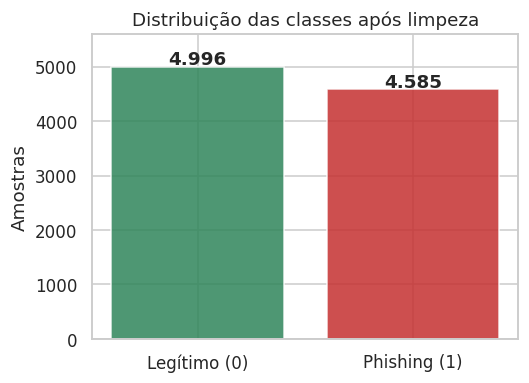

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.6))
counts = df_limpo[config.TARGET].value_counts().sort_index()
ax.bar(["Legítimo (0)", "Phishing (1)"], counts.values,
       color=["#2f855a", "#c53030"], alpha=.85)
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v:,}".replace(",", "."), ha="center", fontweight="bold")
ax.set(ylabel="Amostras", title="Distribuição das classes após limpeza")
ax.set_ylim(0, counts.max() * 1.12)
plt.show()

### O que o balanceamento 48/52 realmente significa

**É uma escolha de coleta.** No tráfego de uma rede
corporativa, phishing não é metade dos acessos, é fração de percentual. A base
foi montada balanceada para facilitar o treino.

Consequência direta: a **acurácia parece razoável aqui justamente porque o
balanceamento a torna interpretável**, e não sobreviveria à prevalência real.
Isso confirma, por um caminho independente, a decisão tomada antes de abrir os
dados, usar PR-AUC e recall sob orçamento de falso positivo.

E é por isso que a etapa de enquadramento vem antes da EDA: a métrica não foi
escolhida olhando os dados.

---

## 4. O que separa phishing de legítimo?

Correlação ponto-bisserial de cada feature com o alvo. Mede associação
**linear** — árvores capturam relações que isto não vê —, mas é o primeiro
mapa útil do terreno.

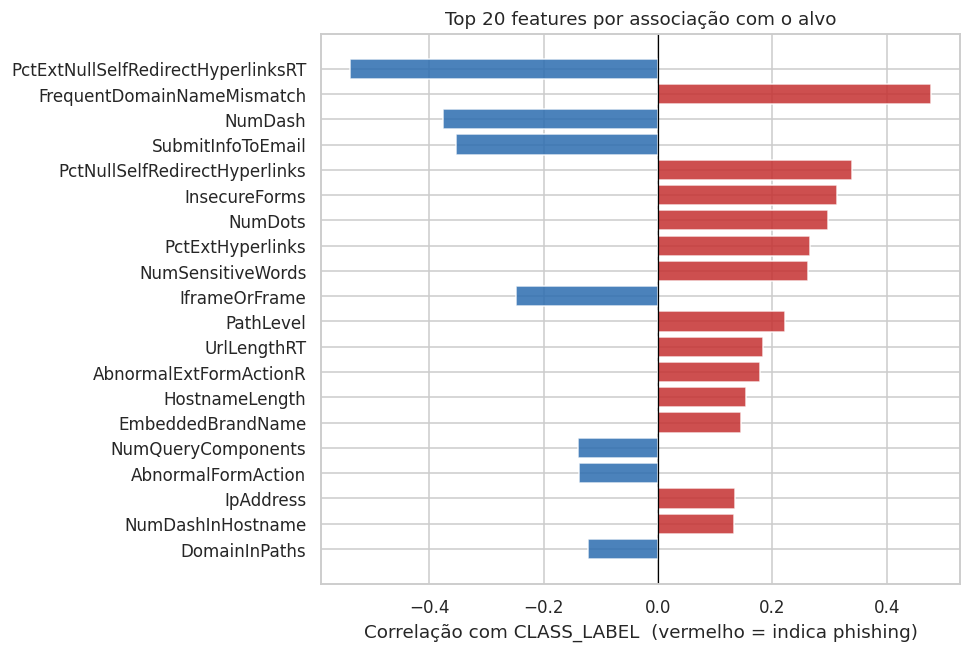

,correlacao
PctExtNullSelfRedirectHyperlinksRT,-0.539
FrequentDomainNameMismatch,0.478
NumDash,-0.376
SubmitInfoToEmail,-0.353
PctNullSelfRedirectHyperlinks,0.340
InsecureForms,0.313
NumDots,0.297
PctExtHyperlinks,0.266


In [10]:
X = df_limpo.drop(columns=[config.TARGET])
y = df_limpo[config.TARGET]

corr = X.corrwith(y).sort_values(key=abs, ascending=False)
top = corr.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
cores = ["#c53030" if v > 0 else "#2b6cb0" for v in top.values]
ax.barh(top.index, top.values, color=cores, alpha=.85)
ax.axvline(0, color="black", lw=.8)
ax.set(xlabel="Correlação com CLASS_LABEL  (vermelho = indica phishing)",
       title="Top 20 features por associação com o alvo")
plt.show()

corr.head(8).to_frame("correlacao").round(3)

As mais associadas ao phishing envolvem **hiperlinks externos**
(`PctExtHyperlinks`, `PctNullSelfRedirectHyperlinks`) e **formulários inseguros**
(`InsecureForms`, `SubmitInfoToEmail`).

Isso é coerente com o modus operandi: a página imita a marca visualmente, mas os
recursos e o destino do formulário apontam para fora do domínio.

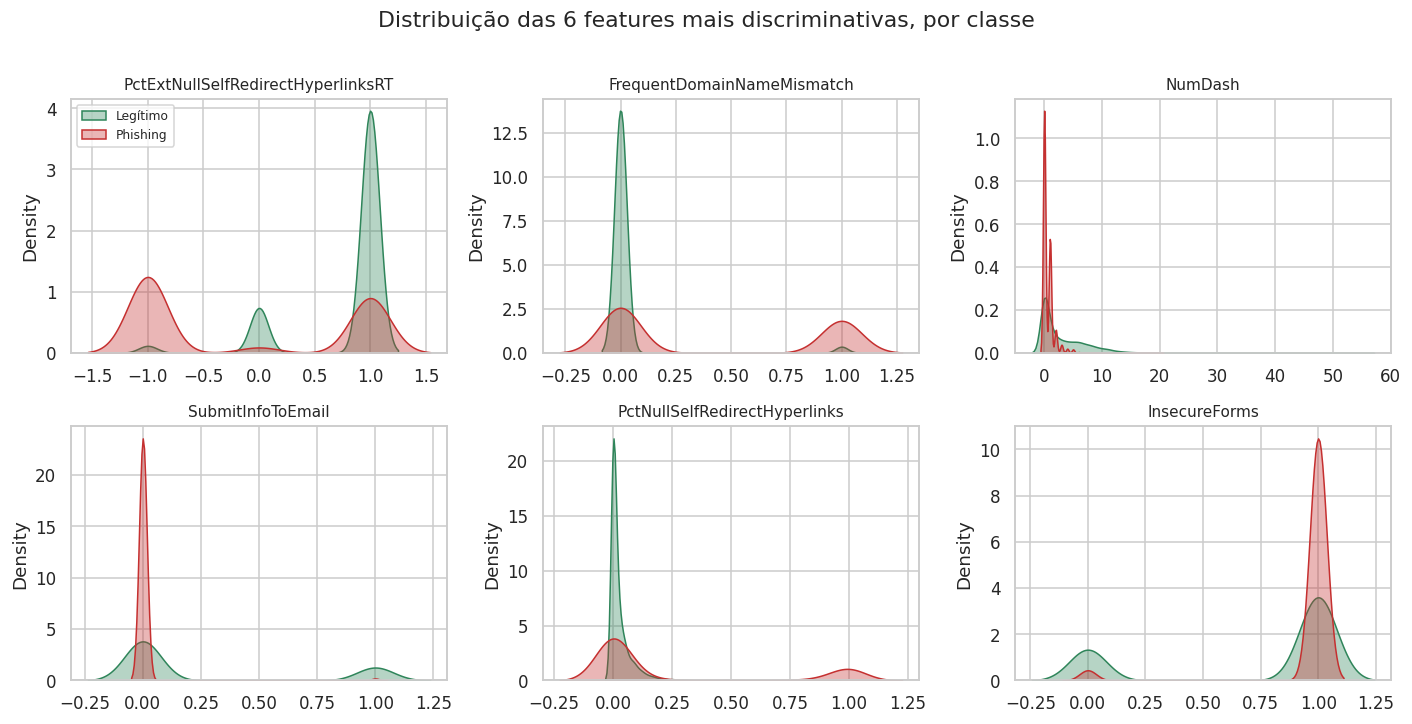

In [11]:
feats_top = corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, f in zip(axes.ravel(), feats_top):
    for label, cor, nome in [(0, "#2f855a", "Legítimo"), (1, "#c53030", "Phishing")]:
        sns.kdeplot(df_limpo.loc[df_limpo[config.TARGET] == label, f], ax=ax,
                    fill=True, alpha=.35, color=cor, label=nome, warn_singular=False)
    ax.set_title(f, fontsize=10)
    ax.set_xlabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Distribuição das 6 features mais discriminativas, por classe", y=1.01)
plt.tight_layout()
plt.show()

A separação é visível mas **parcial** — as distribuições se sobrepõem. Nenhuma
feature isolada resolve o problema, o que justifica usar um modelo em vez de uma
regra fixa do tipo "se `PctExtHyperlinks` > 0.5, bloqueie".

---

## 5. Há redundância entre as features?

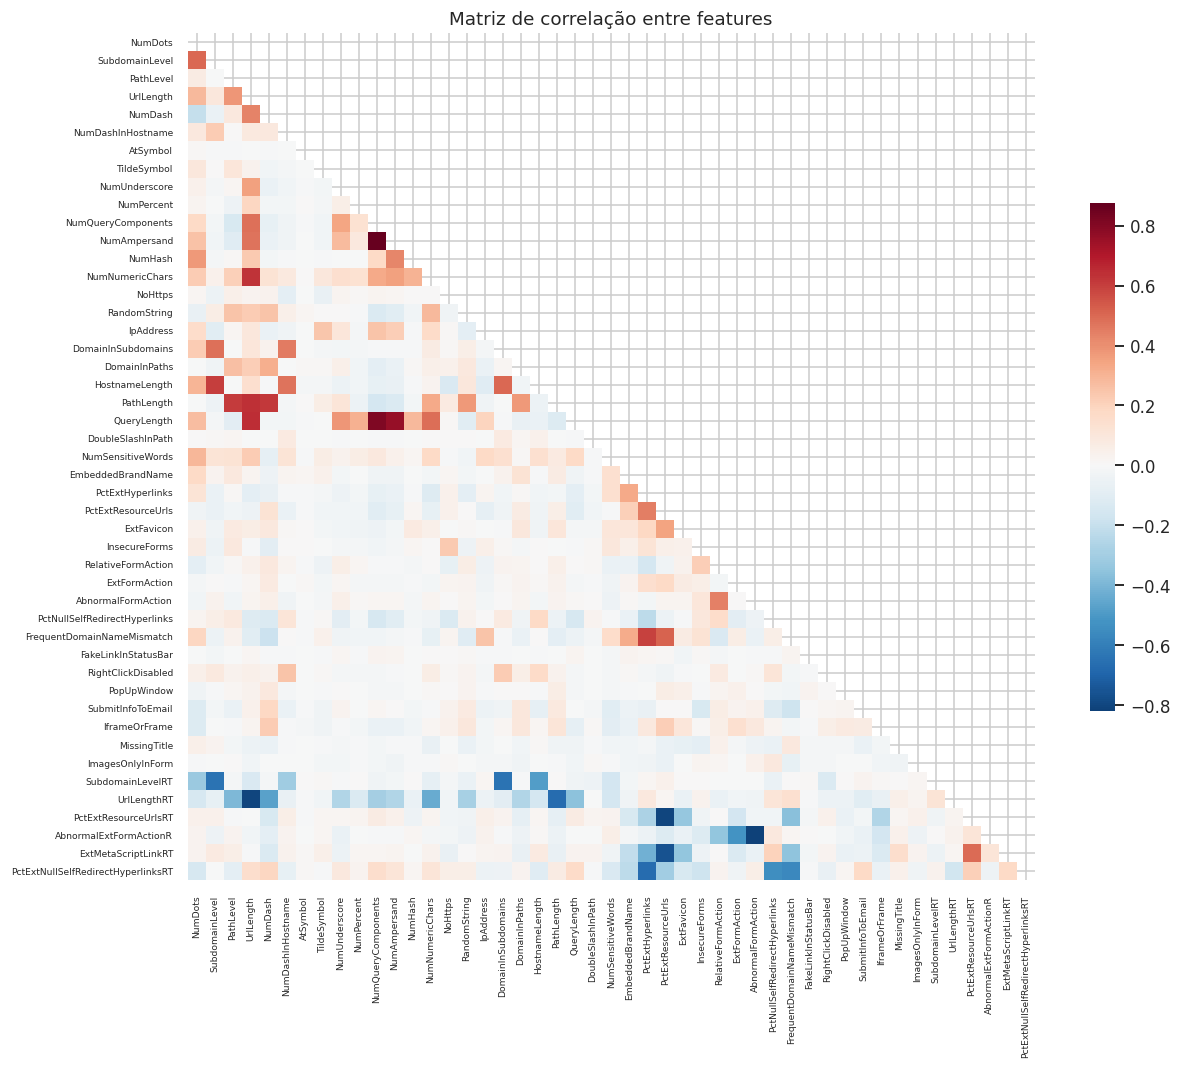

,,correlacao
NumAmpersand,NumQueryComponents,0.877
AbnormalExtFormActionR,AbnormalFormAction,-0.820
QueryLength,NumQueryComponents,0.815
PctExtResourceUrlsRT,PctExtResourceUrls,-0.806
UrlLengthRT,UrlLength,-0.803
ExtMetaScriptLinkRT,PctExtResourceUrls,-0.761
QueryLength,NumAmpersand,0.758


In [12]:
cm = X.corr()
mask = np.triu(np.ones_like(cm, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm, mask=mask, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .6}, ax=ax, xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=6)
ax.set_title("Matriz de correlação entre features")
plt.show()

pares = cm.where(~mask).stack().sort_values(key=abs, ascending=False)
pares[abs(pares) > 0.7].to_frame("correlacao").round(3)

Há pares fortemente correlacionados (comprimentos de URL e path, contadores de
query). Consequências:

- **Para modelos lineares:** infla a variância dos coeficientes — a regressão
  logística fica instável e seus coeficientes, pouco confiáveis para leitura.
- **Para ensembles de árvore:** impacto pequeno no desempenho.
- **Para a interpretação:** afeta bastante. A importância se **dilui** entre
  features redundantes — se duas colunas carregam o mesmo sinal, cada uma parece
  metade do que é.

→ Por isso a etapa de interpretabilidade usa **permutation importance** e
**SHAP**, não a `feature_importances_` padrão do scikit-learn, que é enviesada a
favor de variáveis com muitos valores distintos.

---

## 6. Dá para detectar phishing só com a URL?

Esta é a pergunta de **engenharia**, não de estatística, e a que mais muda a
arquitetura de um sistema real.

- **Features de URL** (`NumDots`, `UrlLength`, `IpAddress`…): calculáveis a
  partir da string, **antes** de o usuário abrir a página. Custo zero de rede.
- **Features de HTML** (`PctExtHyperlinks`, `InsecureForms`…): exigem baixar e
  renderizar o site. Mais caras, e disponíveis só depois que parte do risco já
  se materializou.

>  Para rodar esta seção, adicione `URL_FEATURES`, `HTML_FEATURES` e
> `FEATURE_SETS` ao `config.py` (código no chat).

In [13]:
linhas = []
for nome, cols in config.FEATURE_SETS.items():
    presentes = [c for c in cols if c in X.columns]
    linhas.append({
        "conjunto": nome,
        "n_features": len(presentes),
        "|corr| média com o alvo": X[presentes].corrwith(y).abs().mean(),
        "|corr| máxima": X[presentes].corrwith(y).abs().max(),
    })

pd.DataFrame(linhas).round(3)

,conjunto,n_features,|corr| média com o alvo,|corr| máxima
0,url_only,27,0.118,0.376
1,html_only,20,0.176,0.539
2,full,47,0.142,0.539


As features de HTML carregam associação média bem maior. Mas **associação não
é desempenho** — um conjunto de sinais fracos e independentes pode superar um
conjunto de sinais fortes e redundantes.

A medição de verdade é o **estudo de ablação** no notebook 02, treinando o mesmo
modelo em cada conjunto. A hipótese a testar: *só com URL dá para fazer triagem
barata em tempo real, e o HTML fica reservado para a zona cinzenta.*

